# Compaction-driven groundwater flow

## Background
So far we have discussed and modelled groundwater flow that is driven by recharge and discharge at the land surface. This is often called topography-driven flow. This is the main driving force of groundwater flow, especially in the shallow subsurface, i.e. the upper ~200 m of the earth's crust. However, there are also other processes that can drive groundwater flow.

## Compaction-driven flow
One other driving force for groundwater flow is compaction. If a stress is applied to sediments they compact, and lose pore volume. The groundwater in these pores is squeezed out, which then generates groundwater flow. Alternatively, if the permeability is too low for the water to be squeezed out after compaction, the remaining water will occupy a smaller porespace, but at a much higher pressure.

## Causes for compaction
The most common cause of compaction is sedimentation. In sedimentary basins, new sediment is continually deposited at the surface (or seafloor). As the sediment column grows, older sediment is buried to greater depths and subjected to increasing overburden stress, which results in compaction of the sediments. However, compaction can also be caused by other processes that add a load on sediments, such as loading by glaciers, ice-sheets, or thrust sheets.

![](https://static.wixstatic.com/media/f11012_e4ee4f3d218f4f7bb0b53df28d2dba61~mv2.jpg)

**Example of the exponential decrease in porosity with increasing depth and effective stress for clays. Source: Mondol et al. (2007, https://doi.org/10.1016/j.marpetgeo.2007.03.006)

## Effective stress
An additional cause of compaction can be a decrease in fluid pressure or hydraulic head, which is often caused by groundwater pumping. The stress that a sediment feels is the effective stress, which is the total stress minus the pore fluid pressure. In other words, the stress on sediments by an overlying load is counteracted by the pore pressure. If the pore pressure drops due to pumping, the effective stress increases, and sediments can compact. This is the cause for compaction and land-subsidence in many areas that have experienced high rates of pumping, with the most famous example probably the San-Joaquin Valley in California, USA, and other examples like Mexico city or Jakarta, Indonesia.

![](https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs10040-011-0775-5/MediaObjects/10040_2011_775_Fig1_HTML.gif?as=webp)

**Approximate elevation of the land-surface over time in the San Joaquin Valley. Source: USGS**


## Overpressure
If the pore fluid can drain fast enough during compaction of the sediments, pore pressure remains close to **hydrostatic**. This means that the pressure is equal to the weight of the overlying column of groundwater, or $P_{hydrostatic}=\rho_f g z$, where $\rho_f$ is fluid density, $g$ is gravitational accelleration and $z$ is depth below the water table. But if sedimentation is rapid or permeability is low, groundwater cannot escape quickly enough and **overpressure** develops pore pressure rises above hydrostatic. Overpressure is important because it:
- It can prevent further compaction
- Can trigger fracturing of the host rock
- Controls fluid migration and trapping of hydrocarbons
- Affects borehole stability during drilling

![](https://github.com/ElcoLuijendijk/GEOV212_hydrogeology_exercises/blob/main/fig/overpressure_southern_north_sea.jpg?raw=1)

**Overpressure in the Southern North Sea (Source: Fossen, Structural Geology)**

## Physics

In this notebook we will simulate compaction and compaction-driven flow in a sedimentary basin. Similarly to exercise 3, we will model transient groundwater flow. The main change in comparison to exercise 3 is that we include an additional source term that represents groundwater that is being squeezed out of the sediment due to compaction.


### Porosity-effective stress relationship

The decrease in porosity with increasing effective stress can often be modelled using an exponential decrease. The equation that is used for this is often called the Athy equation, after the scientist that came up with this equation in the 1930's. The equation looks like this:

$$\phi = \phi_0 \, \exp\!\left(-\beta \, \sigma'\right)$$

where:
- $\phi_0$ = porosity at the land surface or seafloor
- $\beta$ [Pa$^{-1}$] = compressibility coefficient controlling how fast porosity decreases with depth and effective stress.
- $\sigma' = P_{lith} - P$ = effective stress (lithostatic pressure minus pore pressure)


### Lithostatic pressure

The lithostatic (overburden) pressure at depth $z$ is a function of the density of the overlying sediments, including their porewater. For a homogenous sediment column with constant density and porosity the equation is:

$$P_{lith} = \rho_{bulk} g z$$

with bulk density a function of the density of pore water ($\rho_f$) and sediment matrix ($\rho_m$) as follows:
$$\rho_{bulk} = \phi \rho_f + (1 - \phi) \rho_m$$

However we will simulate a sedimentary basin where porosity will decrease with depth, so we have to take into account the changing porosity by integrating porosity and density over depth:

$$P_{lith}(z) = \int_0^{z} \rho_{bulk}(z') \, g \, dz'$$


### Governing equation

The 1-D transient groundwater flow equation with a compaction source term is:

$$S_s \frac{\partial h}{\partial t} = \frac{\partial}{\partial z}\!\left(K \frac{\partial h}{\partial z}\right) + Q_{c}$$

where:
- $h$ = hydraulic head (m)
- $S_s$ = specific storage ($m^{-1}$)
- $K$ = hydraulic conductivity ($m s^{-1}$)
- $Q_{c}$ = compaction source term ($s^{-1}$)

### Compaction source term

When porosity decreases by $\Delta\phi$ in a timestep $\Delta t$, the expelled fluid volume per unit bulk volume per unit time is:

$$Q_{c} = -\frac{\Delta \phi}{\Delta t}$$

A decrease in porosity (negative $\Delta\phi$) gives a positive source, driving pore pressure up.

### Hydraulic conductivity - Kozeny-Carman

Hydraulic conducitivity and permeability are strongly dependent on porosity. One way to quantify this is to use the Kozeny-Carman equation. This is a theoretical equation to calculate permeability.

The original form of the equation is

$$k = \dfrac{1}{C S_a} \dfrac{phi^3}{(1-\phi)^2}$$

where $C$ is a constant and $S_a$ is the specific surface area, the contact area between the porewater and the sediment.

We can rewrite this to calculate the decrease in hydraulic condcutivity with depth using a reference value of $K$ at the land surface or the seafloor.

$$K(\phi) = K_{ref} \frac{\phi^3}{(1-\phi)^2} \cdot \frac{(1-\phi_{ref})^2}{\phi_{ref}^3}$$

This ensures $K = K_{ref}$ at $\phi = \phi_{ref}$, and that $K$ decreases as porosity decreases with compaction.


### Sedimentation

One additional challenge that we have to solve is how to simulate sedimentation. We model sedimentation by growing the model grid from the top: at each sedimentation step a new node is added as the first node for all arrays (depth, porosity, etc..), representing freshly deposited, uncompacted sediment. The top node is always at hydrostatic pressure. All existing nodes shift one position deeper.

## Workflow

The code below is a complete code to simulate compaction-driven flow in a sedimentary basin. The code generates several figures and an animation. There are a number of parameters that you can change, including sedimentation rates, compressibility, and hydraulic conductivity, which will affect compaction-driven flow and pore pressure in the basin.

The workflow for this exercise is as follows:

1. **Default run** - Run the model and observe where overpressure develops. Why does it build up near the base rather than the top?
2. **Compressibility** - Vary `beta` (the compaction coefficient). How does it affect the magnitude and depth distribution of overpressure?
3. **Sedimentation rate** - Vary `sed_rate`. How does the magnitude and depth distribution of overpressure change as burial rate increases?
4. **Hydraulic conductivity** - Replace Kozeny-Carman with a constant `K`. What changes, and why?
5. **(Optional)** At what overpressure level (fraction of lithostatic pressure) would hydraulic fracturing be expected? Mark this level on your overpressure plot.

## Import python modules

We start by importing several Python modules, such as numpy and matplotlib

In [1]:
import matplotlib

%matplotlib inline

import numpy as np
import matplotlib.pyplot as pl

## Helper functions

Below are some helper functions to calculate pressure, porosity, and the compaction source term

In [2]:
def compute_lithostatic_pressure(depth, phi, rho_grain, rho_fluid, g):
    """
    Compute lithostatic (overburden) pressure by integrating bulk density downward.
    depth  : depth array [m], depth[0] = top surface, increasing downward
    phi    : porosity array (same length as depth)
    Returns P_lith [Pa] at each node.
    """

    # get the distance between nodes (assuming uniform spacing)
    dz = depth[1] - depth[0] if len(depth) > 1 else depth[0]

    # calculate bulk density at each depth
    rho_bulk = phi * rho_fluid + (1.0 - phi) * rho_grain

    # go through all nodes and calculate lithostatic pressure by adding bulk density * g * dz
    P_lith = np.zeros_like(depth)
    for i in range(1, len(depth)):
        P_lith[i] = P_lith[i-1] + 0.5 * (rho_bulk[i-1] + rho_bulk[i]) * g * dz

    return P_lith


def compute_porosity(sigma_eff, phi_0, beta):
    """
    Exponential (Athy-type) porosity law.
        phi = phi_0 * exp(-beta * sigma_eff)
    sigma_eff : effective stress [Pa]
    phi_0     : surface (depositional) porosity [-]
    beta      : compaction coefficient [Pa^-1]
    """

    phi = phi_0 * np.exp(-beta * sigma_eff)

    return phi


def compute_K_kozeny(phi, K_ref, phi_ref):
    """
    Kozeny-Carman permeability-porosity relationship.
    Normalised so that K = K_ref when phi = phi_ref.
        K(phi) = K_ref * [phi^3 / (1-phi)^2] / [phi_ref^3 / (1-phi_ref)^2]
    phi     : porosity array [-]
    K_ref   : reference hydraulic conductivity [m/s]
    phi_ref : reference porosity at which K = K_ref [-]
    """
    norm = (phi_ref**3) / (1.0 - phi_ref)**2
    K = K_ref * (phi**3 / (1.0 - phi)**2) / norm
    return K


def compute_Ss(phi, beta, rho_fluid, g, beta_fluid):
    """
    Specific storage [m^-1].
    Contributions from fluid compressibility and pore compressibility
    (the latter derived from the exponential porosity law: beta_c = phi * beta).
        Ss = rho_f * g * (phi * beta_f + phi * beta)
    """
    beta_c = phi * beta
    return rho_fluid * g * (phi * beta_fluid + beta_c)


def compaction_source(phi_old, phi_new, dt):
    """
    Fluid source rate due to compaction [s^-1].
    A decrease in porosity expels fluid, acting as a positive pressure source.
        Q_c = -d(phi)/dt
    """
    return -(phi_new - phi_old) / dt

## Model parameters

The default parameters represent a generic deep sedimentary basin that roughly corresponds to the deeper parts of the North Sea Basin.

In [3]:
# seconds per year
year = 365.25 * 24.0 * 3600.0
# seconds per million years
Ma   = 1.0e6 * year

# gravitational acceleration [m/s^2]
g          = 9.81
# seawater density [kg/m^3]
rho_fluid  = rho_f = 1025.0
# quartz/clay grain density [kg/m^3]
rho_grain  = 2650.0
# fluid compressibility [Pa^-1]
beta_fluid = 4.6e-10

# depositional (surface) porosity [-]
# use values of 0.40-0.60 for typical marine sediments
phi_0      = 0.50
# compaction coefficient [Pa^-1]
# ~3e-8 Pa^-1: moderate compactibility (silty clay)
# lower values = stiffer (sandstone), higher = more compressible
beta       = 3.0e-8

# reference hydraulic conductivity [m/s] at phi_ref
# ~1e-11 m/s is typical for marine clay/shale — low enough that overpressure
# develops at sedimentation rates of ~500 m/Ma. Raising this to 1e-9 or higher
# will result in well-drained (hydrostatic) conditions.
K_ref      = 1.0e-11  # this is a clay LH
# K = K_ref at the depositional surface porosity
phi_ref    = phi_0

# node spacing [m]
dz         = 50.0

# 70 m/Ma: typical average for the Central North Sea Cenozoic basin
sed_rate   = 70.0 / Ma
# 65 Ma: full Cenozoic (~4.5 km final column)
t_total    = 65.0 * Ma

# time to deposit one dz-thick layer [s]
dt_sed      = dz / sed_rate
# total sedimentation steps
n_sed_steps = int(t_total / dt_sed)

# save ~20 snapshots during the run
save_interval  = max(1, n_sed_steps // 20)

print('Sedimentation rate  : ', sed_rate * Ma, ' m/Ma')
print('Total time          : ', t_total / Ma, ' Ma')
print('Final column depth  : ', n_sed_steps * dz, ' m  (', n_sed_steps * dz / 1000, ' km)')
print('Number of sed steps : ', n_sed_steps)

Sedimentation rate  :  70.0  m/Ma
Total time          :  65.0  Ma
Final column depth  :  4550.0  m  ( 4.55  km)
Number of sed steps :  91


## The actual groundwater flow model code

 In the previous exercise we used a so-called explicit method where we first calculated hydraulic head, then groundwater flux and then updated the hydraulic head in a new timestep, based on the flux calculated in the previous timestep. The advantage of this method is that it is relatively simple, and the actual groundwater model code was just three lines of Python code. However, the disadvantage is that is can become numerically unstable and that timesteps need to be kept relatively small.

For this exercise we use a different strategy to solve the groundwater flow equation. The  reason is that compaction in sedimentary basins develops over long timescales, and the small timesteps of the explicit method results in really long runtimes (I have tried).

Instead we will use a so-called implicit solution method. Here we calculate the flux and the hydraulic head in the same timestep. Since the flux and hydraulic head depend on each other we need to somehow solve a system of equations. We will not go too much into the theory of how to do this here, but there are several methods available for implicit solutions of the groundwater equation or other diffusion equations.

You can find the code that solves transient groundwater flow including the compaction source term below:


In [4]:
def solve_flow_implicit(h, K, Ss, Qc, dz, dt, h_top=0.0):
    """
    Solve one timestep of the 1-D diffusion equation using the fully implicit
    (backward Euler) scheme:

        Ss * (h_new - h) / dt = d/dz[ K * dh_new/dz ] + Qc

    Because all spatial terms are evaluated at the NEW time level, the scheme
    is always stable. There is no CFL restriction on the timestep, such as we
    had to worry about with the explicit scheme.

    The equation at each node is discretised as:

      Ss[i]/dt * h_new[i]
        - K_face[i-1]/dz^2 * h_new[i-1]
        + (K_face[i-1] + K_face[i])/dz^2 * h_new[i]
        - K_face[i]/dz^2   * h_new[i+1]
      = Ss[i]/dt * h[i] + Qc[i]

    This gives one equation per node, with contributions from the node itself
    and its two neighbours (except at the boundaries). The coefficients of
    h_new[i-1], h_new[i], and h_new[i+1] form the three diagonals of a tridiagonal
    matrix A, and the right-hand side is the vector b.
    We can then solve the linear system A * h_new = b to get the updated head
    values at the new time level.

    We can solve this matrix equation directly with Numpy's linear solver (np.linalg.solve).

    Boundary conditions
    -------------------
    Top    (node 0)  : prescribed head h_new[0] = h_top  (Dirichlet)
    Bottom (node -1) : no-flow, dh/dz = 0                (Neumann)

    Parameters
    ----------
    h     : hydraulic head at current time [m],  array length N
    K     : hydraulic conductivity [m/s],         array length N
    Ss    : specific storage [1/m],               array length N
    Qc    : compaction source term [1/s],         array length N
    dz    : uniform node spacing [m]
    dt    : timestep [s]
    h_top : prescribed head at the top node [m]  (default 0 = hydrostatic)

    Returns
    -------
    h_new : updated hydraulic head [m], array length N
    """
    N = len(h)

    # Harmonic mean conductivity at the N-1 inter-node faces.
    # The harmonic mean is the correct average for resistances (conductivities) in series.
    K_face = 2.0 * K[:-1] * K[1:] / (K[:-1] + K[1:])

    # ----------------------------------------------------------------
    # Build the three diagonals of the tridiagonal matrix A
    # ----------------------------------------------------------------

    # Sub-diagonal: coefficient of h_new[i-1] in equation for node i
    lower = -K_face / dz**2          # length N-1

    # Super-diagonal: coefficient of h_new[i+1] in equation for node i
    upper = -K_face / dz**2          # length N-1

    # Main diagonal: storage term + conductivity contributions from both faces
    main = Ss / dt
    # Top node: only the face below it (face 0) contributes
    main[0]    += K_face[0] / dz**2
    # Interior nodes: faces on both sides
    main[1:-1] += (K_face[:-1] + K_face[1:]) / dz**2
    # Bottom node: only the face above it (face N-2); no face below = no-flow BC
    main[-1]   += K_face[-1] / dz**2

    # Right-hand side: old head scaled by storage, plus compaction source
    b = Ss / dt * h + Qc

    # Assemble the full matrix from the three diagonals
    A = np.diag(main) + np.diag(lower, -1) + np.diag(upper, +1)

    # ----------------------------------------------------------------
    # Apply boundary conditions by overwriting the relevant rows
    # ----------------------------------------------------------------

    # Top node — specified head: replace equation with 1*h_new[0] = h_top
    A[0, :] = 0.0
    A[0, 0] = 1.0
    b[0]    = h_top

    # Bottom node — no-flow: already handled naturally above because the matrix
    # was built without an upper face for the last node (no super-diagonal there).

    # ----------------------------------------------------------------
    # Solve A * h_new = b
    # ----------------------------------------------------------------
    # np.linalg.solve uses LU decomposition. For large grids (N >> 500) a
    # dedicated banded solver (scipy.linalg.solve_banded) would be faster,
    # but for the grid sizes here this is fine.
    h_new = np.linalg.solve(A, b)

    return h_new

## The main simulation loop:

The code below goes through several sedimentation steps where sediment is added to the top of the system and all the existing sediment is shifter downwards. For each sedimentation step, the code solves the groundwater flow equation using the function above.

In [5]:
snapshots    = []
sim_time     = 0.0
h            = np.array([0.0])
phi          = np.array([phi_0])
depth        = np.array([0.0])

for i_sed in range(n_sed_steps):

    # 1. Deposit a new layer at the top; shift existing nodes down by dz
    depth = np.concatenate(([0.0],   depth + dz))
    phi   = np.concatenate(([phi_0], phi))
    h     = np.concatenate(([0.0],   h))

    # Lithostatic pressure from the weight of overlying sediment
    P_lith = compute_lithostatic_pressure(depth, phi, rho_grain, rho_f, g)

    # Calculate pore pressure from hydraulic head
    P     = rho_f * g * (depth + h)

    # calculate effective pressure (clipped at zero to prevent tensile fracture)
    P_eff = np.maximum(P_lith - P, 0.0)   # clip at zero (no tensile fracture)

    # Update porosity based on effective pressure
    phi_old = phi.copy()
    phi_new = compute_porosity(P_eff, phi_0, beta)

    # calculate a new value of hydraulic conductivity based on the updated porosity
    K       = compute_K_kozeny(phi_new, K_ref, phi_ref)

    # calculate a new value of specific storage based on the updated porosity
    Ss      = compute_Ss(phi_new, beta, rho_f, g, beta_fluid)

    # Compaction source: fluid expelled because porosity decreased this step
    Qc = compaction_source(phi_old, phi_new, dt_sed)

    # Solve the flow equation for this sedimentation timestep
    h   = solve_flow_implicit(h, K, Ss, Qc, dz, dt_sed)

    # update porosity for the next iteration
    phi = phi_new

    # add time step to total simulation time
    sim_time += dt_sed

    # Save snapshot every save_interval steps and at the final step
    if i_sed % save_interval == 0 or i_sed == n_sed_steps - 1:
        snapshots.append({
            'time_Ma': sim_time / Ma,
            'z'      : depth.copy(),
            'h'      : h.copy(),
            'phi'    : phi.copy(),
        })

    # Progress report
    if (i_sed + 1) % max(1, n_sed_steps // 5) == 0:
        print('t = ', sim_time/Ma, ' Ma | depth = ', depth[-1]/1000, ' km | ',
              'max h = ', h.max(), ' m | min phi = ', phi.min())

print('Simulation complete. Total sedimentation steps: ', n_sed_steps)

t =  12.857142857142858  Ma | depth =  0.9  km |  max h =  15.126017497284785  m | min phi =  0.39682079398002834
t =  25.714285714285722  Ma | depth =  1.8  km |  max h =  76.07601010484223  m | min phi =  0.30639746565152326
t =  38.57142857142857  Ma | depth =  2.7  km |  max h =  210.16154800843768  m | min phi =  0.23384325736561945
t =  51.42857142857137  Ma | depth =  3.6  km |  max h =  439.00124579494025  m | min phi =  0.17897880135251093
t =  64.28571428571416  Ma | depth =  4.5  km |  max h =  768.9028082755997  m | min phi =  0.1385373458710862
Simulation complete. Total sedimentation steps:  91


## Post-processing: compute overpressure

Overpressure = excess pore pressure above hydrostatic:

$$P_{excess}(z) = P(z) - P_{hydrostatic}(z) = \rho_f g \, h(z)$$

where $h$ is the hydraulic head (excess above hydrostatic, which is our reference). A positive $h$ means the pore pressure is above hydrostatic.

In [6]:
for snap in snapshots:
    # [Pa]
    snap['overpressure'] = rho_fluid * g * snap['h']
    snap['P_lith'] = compute_lithostatic_pressure(
        snap['z'], snap['phi'], rho_grain, rho_fluid, g)

## Depth profiles over time

Each coloured line is a snapshot at a different time. The four panels show porosity $\phi$, hydraulic conductivity $K$, hydraulic head $h$ (excess above hydrostatic), and overpressure vs depth.

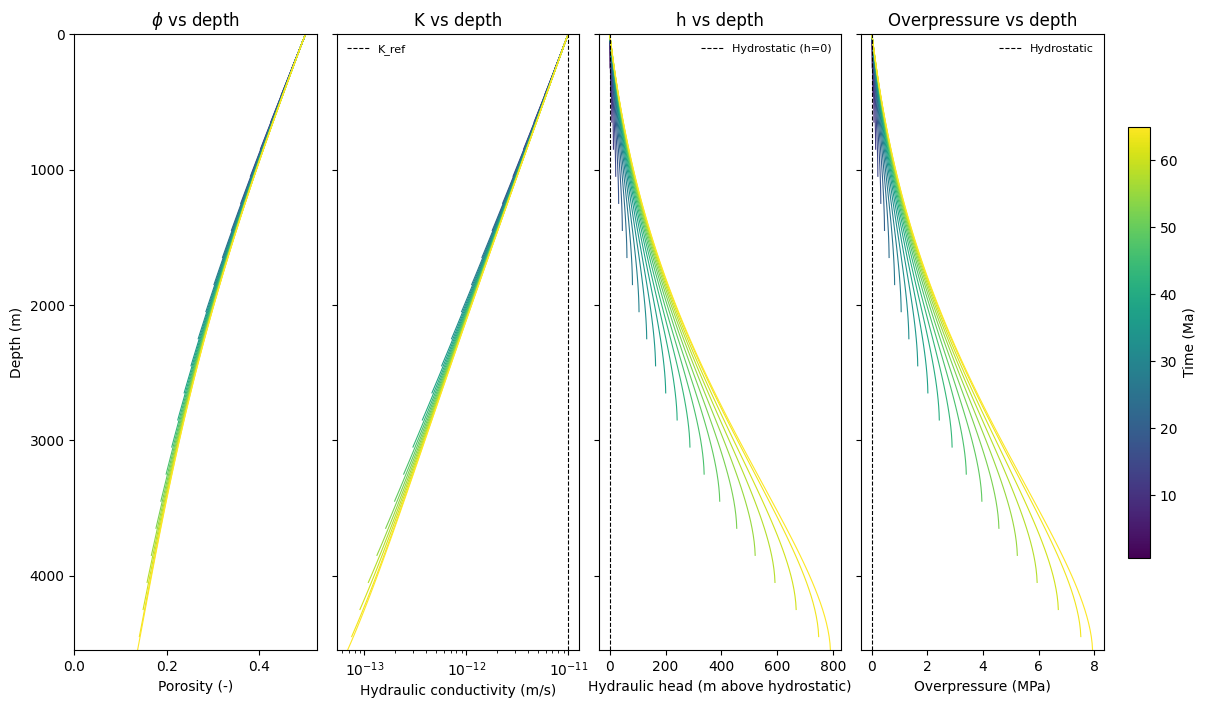

In [7]:
fig, axes = pl.subplots(1, 4, figsize=(16, 8), sharey=True)
fig.subplots_adjust(wspace=0.08)

cmap   = pl.cm.viridis
times  = np.array([s['time_Ma'] for s in snapshots])
t_norm = (times - times.min()) / (times.max() - times.min() + 1e-12)
z_bot  = snapshots[-1]['z'][-1]

# --- Panel 1: Porosity ---
ax = axes[0]
for snap, tn in zip(snapshots, t_norm):
    ax.plot(snap['phi'], snap['z'], color=cmap(tn), lw=0.8)
ax.set_xlabel('Porosity (-)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0, phi_0 * 1.05)
ax.set_ylim(z_bot, 0)
ax.set_title(r'$\phi$ vs depth')

# --- Panel 2: Hydraulic conductivity (log scale) ---
ax = axes[1]
for snap, tn in zip(snapshots, t_norm):
    K_snap = compute_K_kozeny(snap['phi'], K_ref, phi_ref)
    ax.semilogx(K_snap, snap['z'], color=cmap(tn), lw=0.8)
ax.axvline(K_ref, color='k', ls='--', lw=0.8, label='K_ref')
ax.set_xlabel('Hydraulic conductivity (m/s)')
ax.set_ylim(z_bot, 0)
ax.set_title('K vs depth')
ax.legend(fontsize=8, frameon=False)

# --- Panel 3: Hydraulic head ---
ax = axes[2]
for snap, tn in zip(snapshots, t_norm):
    ax.plot(snap['h'], snap['z'], color=cmap(tn), lw=0.8)
ax.axvline(0, color='k', lw=0.8, ls='--', label='Hydrostatic (h=0)')
ax.set_xlabel('Hydraulic head (m above hydrostatic)')
ax.set_ylim(z_bot, 0)
ax.set_title('h vs depth')
ax.legend(fontsize=8, frameon=False)

# --- Panel 4: Overpressure ---
ax = axes[3]
for snap, tn in zip(snapshots, t_norm):
    ax.plot(snap['overpressure'] / 1e6, snap['z'], color=cmap(tn), lw=0.8)
ax.axvline(0, color='k', lw=0.8, ls='--', label='Hydrostatic')
ax.set_xlabel('Overpressure (MPa)')
ax.set_ylim(z_bot, 0)
ax.set_title('Overpressure vs depth')
ax.legend(fontsize=8, frameon=False)

# --- Shared colorbar ---
sm = pl.cm.ScalarMappable(cmap=cmap,
                           norm=pl.Normalize(vmin=times.min(), vmax=times.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label('Time (Ma)')

fig.savefig('compaction_depth_profiles.png', dpi=150)
pl.show()

## Figure 4 - Overpressure at the base of the column over time

The deepest (oldest) node experiences the greatest burial. This plot shows how its overpressure accumulates through time.

Final overpressure at base :  7.944266330762727  MPa
Final lithostatic at base  :  97.00049045669867  MPa
Overpressure / lithostatic :  0.08189923879105615


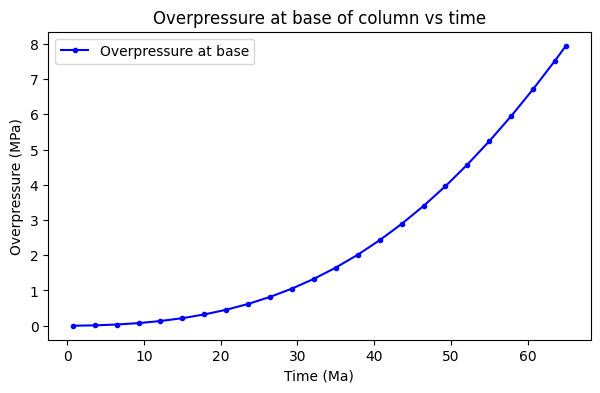

In [8]:
snap_times = np.array([s['time_Ma']          for s in snapshots])
# MPa
base_overp = np.array([s['overpressure'][-1] for s in snapshots]) / 1e6
# MPa
base_plith = np.array([s['P_lith'][-1]       for s in snapshots]) / 1e6

fig, panel = pl.subplots(figsize=(7, 4))
panel.plot(snap_times, base_overp, 'b-o', ms=3, label='Overpressure at base')
panel.set_xlabel('Time (Ma)')
panel.set_ylabel('Overpressure (MPa)')
panel.set_title('Overpressure at base of column vs time')
panel.legend()
fig.savefig('compaction_overpressure_over_time.png', dpi=150)

print('Final overpressure at base : ', base_overp[-1], ' MPa')
print('Final lithostatic at base  : ', base_plith[-1], ' MPa')
if base_plith[-1] > 0:
    print('Overpressure / lithostatic : ', base_overp[-1] / base_plith[-1])

## Animation — Pressure & Darcy flux vs depth over time

Two-panel animation showing how **pore pressure** evolves relative to the hydrostatic and lithostatic reference pressures (left panel), and how the **Darcy flux** changes with depth (right panel), as the sediment column grows and compaction proceeds.

In [9]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── Pre-compute derived quantities for every snapshot ──────────────────────────
year_s = 365.25 * 24.0 * 3600.0   # s / yr

for snap in snapshots:
    z_s    = snap['z']
    h_s    = snap['h']
    phi_s  = snap['phi']

    # Hydrostatic pressure  [Pa]
    snap['P_hydrostatic'] = rho_fluid * g * z_s

    # Total pore pressure   [Pa]  =  hydrostatic  +  overpressure
    snap['P_pore'] = rho_fluid * g * (z_s + h_s)

    # Darcy flux  q = -K * dh/dz  [m/s] → convert to m/yr
    K_s = compute_K_kozeny(phi_s, K_ref, phi_ref)
    if len(z_s) > 1:
        dhdz = np.gradient(h_s, z_s)
    else:
        dhdz = np.zeros_like(h_s)
    snap['q_yr'] = -K_s * dhdz * year_s   # m/yr

# ── Global axis limits (fixed across all frames for comparability) ─────────────
final_snap = snapshots[-1]
z_max      = float(final_snap['z'][-1])           # m  (deepest point)
P_lith_max = float(final_snap['P_lith'][-1]) / 1e6  # MPa

# Darcy-flux range: a little wider than the global extremes
q_all = np.concatenate([s['q_yr'] for s in snapshots])
q_abs = max(np.abs(q_all).max(), 1e-12)
q_lim = q_abs * 1.2                               # m/yr

# ── Build figure ───────────────────────────────────────────────────────────────
fig, (ax1, ax2) = pl.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.subplots_adjust(wspace=0.08)

# --- Panel 1: Pressure ---
line_pore,  = ax1.plot([], [], 'b-',  lw=2,   label='Pore pressure')
line_hydro, = ax1.plot([], [], 'b--', lw=1.2, label='Hydrostatic')
line_lith,  = ax1.plot([], [], 'r-',  lw=1.5, label='Lithostatic')

ax1.set_xlim(0, P_lith_max * 1.05)
ax1.set_ylim(z_max * 1.05, 0)          # depth increases downward
ax1.set_xlabel('Pressure (MPa)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.legend(loc='lower left', fontsize=9)
title_txt = ax1.set_title('', fontsize=12)

# --- Panel 2: Darcy flux ---
line_flux, = ax2.plot([], [], color='forestgreen', lw=2, label='Darcy flux')
ax2.axvline(0, color='k', ls='--', lw=0.8)

ax2.set_xlim(-q_lim, q_lim)
ax2.set_xlabel('Darcy flux (m/yr)', fontsize=12)
ax2.legend(loc='lower right', fontsize=9)
ax2.set_title('Fluid flux vs depth', fontsize=12)

# Add a note about sign convention
ax2.text(0.98, 0.02, '+ = downward', transform=ax2.transAxes,
         ha='right', va='bottom', fontsize=8, color='gray')

# ── Animation update function ──────────────────────────────────────────────────
def _update(frame):
    snap   = snapshots[frame]
    z_f    = snap['z']

    # Pressure panel — all in MPa
    line_pore.set_data(snap['P_pore']        / 1e6, z_f)
    line_hydro.set_data(snap['P_hydrostatic'] / 1e6, z_f)
    line_lith.set_data(snap['P_lith']         / 1e6, z_f)

    # Flux panel
    line_flux.set_data(snap['q_yr'], z_f)

    title_txt.set_text(f"Pressure vs depth    t = {snap['time_Ma']:.2f} Ma")
    return line_pore, line_hydro, line_lith, line_flux, title_txt

ani = FuncAnimation(fig, _update, frames=len(snapshots), blit=False, interval=250)
pl.close(fig)   # prevent static display of final frame

HTML(ani.to_jshtml())


## Assignments


### Assignment 1 - Default run: where does overpressure develop?

Run the default model and examine the depth-profiles figure (four panels: $\\phi$, K, h, overpressure) and the overpressure-over-time figure.

**Questions:**
- Does overpressure develop? Where in the column (top, middle, base)?
- Why is the hydraulic head always zero at the top of the column?
- Why does overpressure build up near the base rather than the top?

---

### Assignment 2 - Effect of compaction coefficient beta

The compaction coefficient $\beta$ controls how rapidly porosity decreases with effective stress. Typical values:
- ~$5 \times 10^{-9} \; Pa^{-1}$: stiff limestone or sandstone
- ~$3 \times 10^{-8} \; Pa^{-1}$: silty clay (default)
- ~$2 \times 10^{-7} \; Pa^{-1}$: very soft mud / peat

**Task:** Repeat the simulation with `beta = 5e-9` and `beta = 2e-7`. Compare the overpressure and porosity profiles.

**Questions:**
- How does increasing `beta` affect the maximum overpressure? Explain physically.
- How does it affect the porosity-depth profile?

---

### Assignment 3 - Effect of sedimentation rate

**Task:** Run three scenarios by changing only `sed_rate`:

| Scenario | `sed_rate` | Context |
|---|---|---|
| Slow | `20 / Ma` | Outer shelf / pelagic setting |
| Default | `70 / Ma` | Central North Sea Cenozoic |
| Fast | `200 / Ma` | Active depocentre (e.g. Paleocene fan system) — also reduce `t_total` to `20 * Ma` to keep the column depth realistic |

**Questions:**
- How does the maximum overpressure (in MPa, and as a fraction of lithostatic pressure) change across the three scenarios?
- Does the depth at which peak overpressure occurs shift between runs? Why?
- The hydraulic diffusion timescale is $\\tau_D = L^2 / D$, where $D = K / S_s$ and $L$ is the column thickness. The burial timescale is $\\tau_B = L / v_s$. Estimate both timescales for each scenario. Is groundwater diffusion faster or slower than burial in these three scenarios? How does this affect compaction-driven flow and overpressure?

---

### Assignment 4 - Effect of permeability model

**Task:** In the main simulation loop, replace the Kozeny-Carman line `K = compute_K_kozeny(phi_new, K_ref, phi_ref)` with a constant value: `K = np.full_like(phi_new, K_ref)`. Run the model and compare with the default result.

**Questions:**
- Does the spatial distribution of overpressure change?
- With Kozeny-Carman, K decreases with depth as porosity decreases. How does this affect the ability of fluid to drain from deep in the column?

---

### Assignment 5 (Optional) - Hydraulic fracturing

Does the model ever reach this threshold?

Hydraulic fracturing occurs when pore pressure exceeds the minimum principal stress, which is approximately the lithostatic pressure multiplied by a stress ratio $\lambda \approx 0.6-0.8$.

$$P_{fracture}(z) = \lambda \cdot P_{lith}(z) - P_{hydrostatic}(z)$$
**Task:** Add a line to the overpressure panel (Panel 4) of the depth-profiles figure that marks the fracturing threshold:

## References

Athy, L. F. (1930). Density, porosity, and compaction of sedimentary rocks. *AAPG Bulletin*, 14(1), 1-24.

Bear, J. (1972). *Dynamics of Fluids in Porous Media*. Dover Publications.

Bethke, C. M. (1985). A numerical model of compaction-driven groundwater flow and heat transfer and its application to the paleohydrology of intracratonic sedimentary basins. *Journal of Geophysical Research*, 90(B8), 6817-6828.

Kozeny, J. (1927). Uber kapillare Leitung des Wassers im Boden. *Sitzungsberichte der Akademie der Wissenschaften in Wien*, 136, 271-306.

Carman, P. C. (1937). Fluid flow through granular beds. *Transactions of the Institution of Chemical Engineers*, 15, 150-166.